In [296]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import random
import time
import matplotlib.pyplot as plt
import numpy as np
from utils import calc_NC1

In [297]:
retrain_mnist_classifier = False

In [298]:
import os

# Improved classifier: use a CNN for MNIST, which can easily reach >99.7% accuracy.
class MNISTCNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  # 28x28 -> 28x28
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), # 28x28 -> 28x28
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                 # 28x28 -> 14x14
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1), # 14x14 -> 14x14
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 14x14 -> 7x7
            nn.Dropout(0.25),
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(128*7*7, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        # x: (batch, 1, 28, 28)
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

def train_classifier(epochs=15, device="cuda"):
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

    clf = MNISTCNNClassifier().to(device)
    opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=7, gamma=0.5)

    for epoch in range(epochs):
        clf.train()
        total = 0
        correct = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = clf(x)
            loss = F.cross_entropy(logits, y)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total += y.size(0)
            correct += (logits.argmax(1) == y).sum().item()

        acc = correct / total * 100
        print(f"Epoch {epoch+1}, Acc: {acc:.2f}%")
        scheduler.step()

    # Optionally, evaluate on the training set for 100% accuracy
    clf.eval()
    with torch.no_grad():
        total = 0
        correct = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = clf(x)
            total += y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
        acc = correct / total * 100
        print(f"Final training accuracy: {acc:.2f}%")
    return clf

device = "cuda"

if not os.path.exists("./saved_models/mnist_classifier.pth") or retrain_mnist_classifier:
    clf = train_classifier(epochs=15, device=device)
    torch.save(clf.state_dict(), "./saved_models/mnist_classifier.pth")


In [299]:
# ----------------------------
# 1. Custom dataset
# ----------------------------
class DigitOffsetDataset(Dataset):
    def __init__(self, mnist_dataset, max_offset=3, max_offset_sample=None):
        """
        mnist_dataset: torchvision.datasets.MNIST
        max_offset: offsets sampled uniformly from [-max_offset, ..., max_offset], excluding 0
        """
        self.mnist = mnist_dataset
        self.max_offset = max_offset
        if max_offset_sample is not None:
            self.max_offset_sample = max_offset_sample
        else:
            self.max_offset_sample = max_offset

        # Precompute indices for each digit
        self.class_to_indices = {i: [] for i in range(10)}
        for idx, (_, label) in enumerate(self.mnist):
            self.class_to_indices[label].append(idx)

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        img, label = self.mnist[idx]  # input digit

        # choose nonzero offset
        offset = random.randint(-self.max_offset_sample, self.max_offset_sample)
        target_digit = label + offset # (label + offset) % 10
        while target_digit < 0 or target_digit > 9:
            offset = random.randint(-self.max_offset_sample, self.max_offset_sample)
            target_digit = label + offset # (label + offset) % 10

        # pick random image of target digit
        target_idx = self.class_to_indices[target_digit][0] # random.choice(self.class_to_indices[target_digit])
        target_img, _ = self.mnist[target_idx]

        # one-hot encode offset in range [-max_offset, max_offset]
        offset_id = offset + self.max_offset  # shift to [0 .. 2*max_offset]
        offset_onehot = F.one_hot(torch.tensor(offset_id), num_classes=2*self.max_offset+1).float()

        return img.view(-1), offset_onehot, target_img.view(-1), label, target_digit


# ----------------------------
# 2. Encoder–Decoder model
# ----------------------------
class DigitTranslator(nn.Module):
    def __init__(self, latent_dim=64, offset_dim=7, n_layers_encoder=2, n_layers_decoder=2):  # offset_dim = 2*max_offset+1
        super().__init__()
        encoder_layers = []
        input_dim = 28*28 + offset_dim
        hidden_dim = 256
    
        # Encoder: input -> hidden layers -> latent
        encoder_layers.append(nn.Linear(input_dim, hidden_dim))
        for _ in range(n_layers_encoder - 2):
            encoder_layers.append(nn.ReLU())
            encoder_layers.append(nn.Linear(hidden_dim, hidden_dim))
        encoder_layers.append(nn.ReLU())
        encoder_layers.append(nn.Linear(hidden_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        # Decoder: latent -> hidden layers -> output
        decoder_layers = []
        decoder_layers.append(nn.Linear(latent_dim, hidden_dim))
        for _ in range(n_layers_decoder - 2):
            decoder_layers.append(nn.ReLU())
            decoder_layers.append(nn.Linear(hidden_dim, hidden_dim))
        decoder_layers.append(nn.ReLU())
        self.decoder = nn.Sequential(*decoder_layers)
        self.output_layer = nn.Linear(hidden_dim, 28*28)

    def forward(self, x, offset_onehot):
        x_input = torch.cat([x, offset_onehot], dim=1)
        h_encoder = self.encoder(x_input)
        h_decoder = self.decoder(h_encoder)
        x_logits = self.output_layer(h_decoder)
        return x_logits
    
    def get_latent(self, x, offset_onehot, layer='encoder'):
        x_input = torch.cat([x, offset_onehot], dim=1)
        x_input = torch.cat([x, offset_onehot], dim=1)
        h_encoder = self.encoder(x_input)
        h_decoder = self.decoder(h_encoder)
        if layer == 'encoder':
            return h_encoder
        elif layer == 'decoder':
            return h_decoder
        elif layer == 'output':
            return x_logits


# ----------------------------
# 3. Training loop
# ----------------------------
def train_model(dataset, epochs=5, batch_size=128, lr=1e-3, max_offset=3, device='cuda', n_layers=2):
    start_time = time.time()
    train_ds = DigitOffsetDataset(mnist_train, max_offset=max_offset)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    model = DigitTranslator(offset_dim=2*max_offset+1, n_layers_encoder=n_layers, n_layers_decoder=n_layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    
    #########################################################
    clf = MNISTCNNClassifier().to(device)
    clf.load_state_dict(torch.load("./saved_models/mnist_classifier.pth"))
    clf.eval()
    for p in clf.parameters():
        p.requires_grad = False
    lambda_clf = 0.0
    #########################################################
    
    # Store loss values for plotting
    epoch_losses = []
    epoch_losses_clf = []
    epoch_losses_rec = []
    batch_losses = []  # For more detailed tracking
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_clf_loss = 0
        total_rec_loss = 0
        epoch_batch_losses = []
        
        for batch_idx, (x, offset, target, label, target_digit) in enumerate(train_loader):
            x, offset, target, label, target_digit = x.to(device), offset.to(device), target.to(device), label.to(device), target_digit.to(device)
            logits = model(x, offset)
            loss = F.binary_cross_entropy_with_logits(logits, target, reduction='mean')
            total_rec_loss += loss.item() * x.size(0)

            #########################################################
            # # Classifier loss on generated image
            logits_reshaped = logits.view(-1, 1, 28, 28)  # reshape to (batch, channels, H, W)
            class_logits = clf(logits_reshaped)  # freeze classifier
            clf_loss = F.cross_entropy(class_logits, target_digit)
            loss += lambda_clf * clf_loss
            total_clf_loss += clf_loss.item() * x.size(0)
            #########################################################

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item() * x.size(0)
            epoch_batch_losses.append(loss.item())
            
            # Store every 10th batch loss for detailed tracking
            if batch_idx % 10 == 0:
                batch_losses.append((epoch * len(train_loader) + batch_idx, loss.item()))

        avg_epoch_loss = total_loss / len(train_loader.dataset)
        avg_epoch_loss_clf = total_clf_loss / len(train_loader.dataset)   
        avg_epoch_loss_rec = total_rec_loss / len(train_loader.dataset)
        epoch_losses.append(avg_epoch_loss)
        epoch_losses_clf.append(avg_epoch_loss_clf)
        epoch_losses_rec.append(avg_epoch_loss_rec)
        elapsed_time = time.time() - start_time
        # Estimate remaining time
        epochs_done = epoch + 1
        epochs_total = epochs
        avg_epoch_time = elapsed_time / epochs_done
        epochs_left = epochs_total - epochs_done
        est_remaining_time = avg_epoch_time * epochs_left
        print(f"Epoch {epoch+1}, Loss: {avg_epoch_loss:.4f}, Elapsed Time: {elapsed_time/60:.2f} minutes, Estimated Remaining Time: {est_remaining_time/60:.2f} minutes")

    return model, epoch_losses, batch_losses, epoch_losses_clf, epoch_losses_rec


# ----------------------------
# 4. Sampling
# ----------------------------
def sample(model, input_img, offset, max_offset, device='cuda'):
    model.eval()
    with torch.no_grad():
        x = input_img.view(1, -1).to(device)
        offset_onehot = F.one_hot(torch.tensor([offset+max_offset]), num_classes=2*max_offset+1).float().to(device)
        logits = model(x, offset_onehot)
        img_out = torch.sigmoid(logits).view(28, 28).cpu()
        return img_out

# ----------------------------
# 5. Plot training loss
# ----------------------------
def plot_training_loss(epoch_losses, batch_losses=None, fig=None, label=None, epoch_losses_clf=None, epoch_losses_rec=None):
    """Plot the training loss throughout training"""
    if not fig:
        fig = plt.figure(figsize=(16, 5))
    
    # Plot epoch losses
    plt.subplot(1, 4, 1)
    plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o', linewidth=2, markersize=8, label=label)
    plt.title('Training Loss per Epoch', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, len(epoch_losses) + 1))
    
    # Plot epoch losses
    plt.subplot(1, 4, 2)
    plt.plot(range(1, len(epoch_losses_clf) + 1), epoch_losses_clf, marker='o', linewidth=2, markersize=8, label=label)
    plt.title('Clf training Loss per Epoch', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, len(epoch_losses) + 1))
    
    # Plot epoch losses
    plt.subplot(1, 4, 3)
    plt.plot(range(1, len(epoch_losses_rec) + 1), epoch_losses_rec, marker='o', linewidth=2, markersize=8, label=label)
    plt.title('Rec training Loss per Epoch', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, len(epoch_losses) + 1))
    
    # Plot batch losses if available
    if batch_losses:
        plt.subplot(1, 4, 4)
        batch_indices, batch_loss_values = zip(*batch_losses)
        plt.plot(batch_indices, batch_loss_values, alpha=0.7, linewidth=1, label=label)
        plt.title('Training Loss per Batch', fontsize=14)
        plt.xlabel('Batch Index', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if fig is None:
        plt.show()

In [300]:
import torch
import os

from torch.multiprocessing import Process, set_start_method

def train_and_save_model(mnist_train, max_offset, device, save_dir, epochs=3, n_layers=4, lr=1e-3, batch_size=128):
    print(f"Training model for max_offset={max_offset} on {device}")
    model, epoch_losses, batch_losses, epoch_losses_clf, epoch_losses_rec = train_model(
        dataset=mnist_train, epochs=epochs, device=device, max_offset=max_offset, n_layers=n_layers, lr=lr, batch_size=batch_size
    )
    print(f'Saving model for max_offset={max_offset} to {save_dir}')
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"model_max_offset_{max_offset}.pt")
    torch.save({
        'model_state_dict': model.state_dict(),
        'epoch_losses': epoch_losses,
        'batch_losses': batch_losses,
        'max_offset': max_offset,
        'epoch_losses_clf': epoch_losses_clf,
        'epoch_losses_rec': epoch_losses_rec
    }, save_path)
    print(f"Saved model for max_offset={max_offset} to {save_path}")
    return model, epoch_losses, batch_losses, epoch_losses_clf, epoch_losses_rec

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t: t.view(-1))  # flatten
])
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
max_move_l = np.arange(10)
n_layers = 4
epochs = 100
lr = 1e-4
batch_size = 2048
device = "cuda"
save_dir = "./saved_models"
# for max_offset in max_move_l:
#     model, epoch_losses, batch_losses, epoch_losses_clf, epoch_losses_rec = train_and_save_model(mnist_train, max_offset, device, save_dir, n_layers=n_layers, epochs=epochs, lr=lr, batch_size=batch_size)


In [ ]:
from joblib import Parallel, delayed
num_gpus = torch.cuda.device_count()
# Run in parallel
paths = Parallel(n_jobs=-1)(
    delayed(train_and_save_model)(mnist_train, max_offset, f'{device}:{max_offset % num_gpus}', save_dir, n_layers=n_layers, epochs=epochs, lr=lr, batch_size=batch_size) for max_offset in max_move_l
)

Input digit: 4 offset: -2


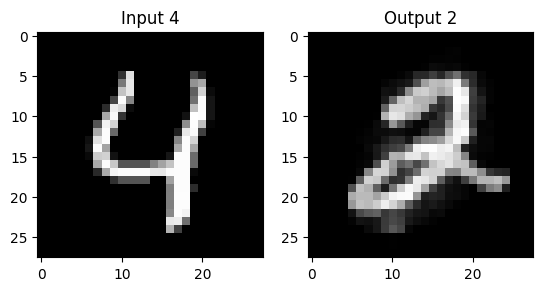

Input digit: 4 offset: -1


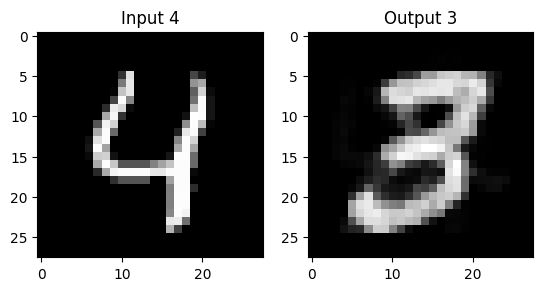

Input digit: 4 offset: 0


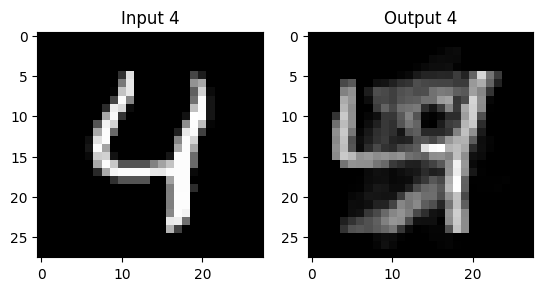

Input digit: 4 offset: 1


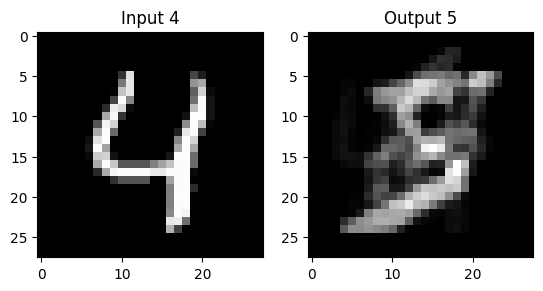

Input digit: 4 offset: 2


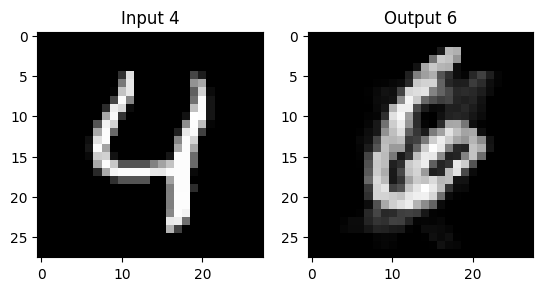

In [ ]:
max_offset = max_move_l[2]
model_path = f"{save_dir}/model_max_offset_{max_offset}.pt"
checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)
model = DigitTranslator(offset_dim=2*max_offset+1, n_layers_encoder=n_layers, n_layers_decoder=n_layers).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
for offset in np.arange(-max_offset, max_offset+1):
# Take an MNIST test image "3" and offset +2 -> "5"
    test_ds = datasets.MNIST(root="./data", train=False, download=True,
                                transform=transforms.ToTensor())
    img, label = test_ds[4]  # first test image
    print("Input digit:", label, "offset:", offset)

    out_img = sample(model, img, offset=offset, device=device, max_offset=max_offset)

    import matplotlib.pyplot as plt
    plt.subplot(1, 2, 1)
    plt.title(f"Input {label}")
    plt.imshow(img.squeeze(), cmap="gray")
    plt.subplot(1, 2, 2)
    plt.title(f"Output {(label+offset)%10}")
    plt.imshow(out_img, cmap="gray")
    plt.show()

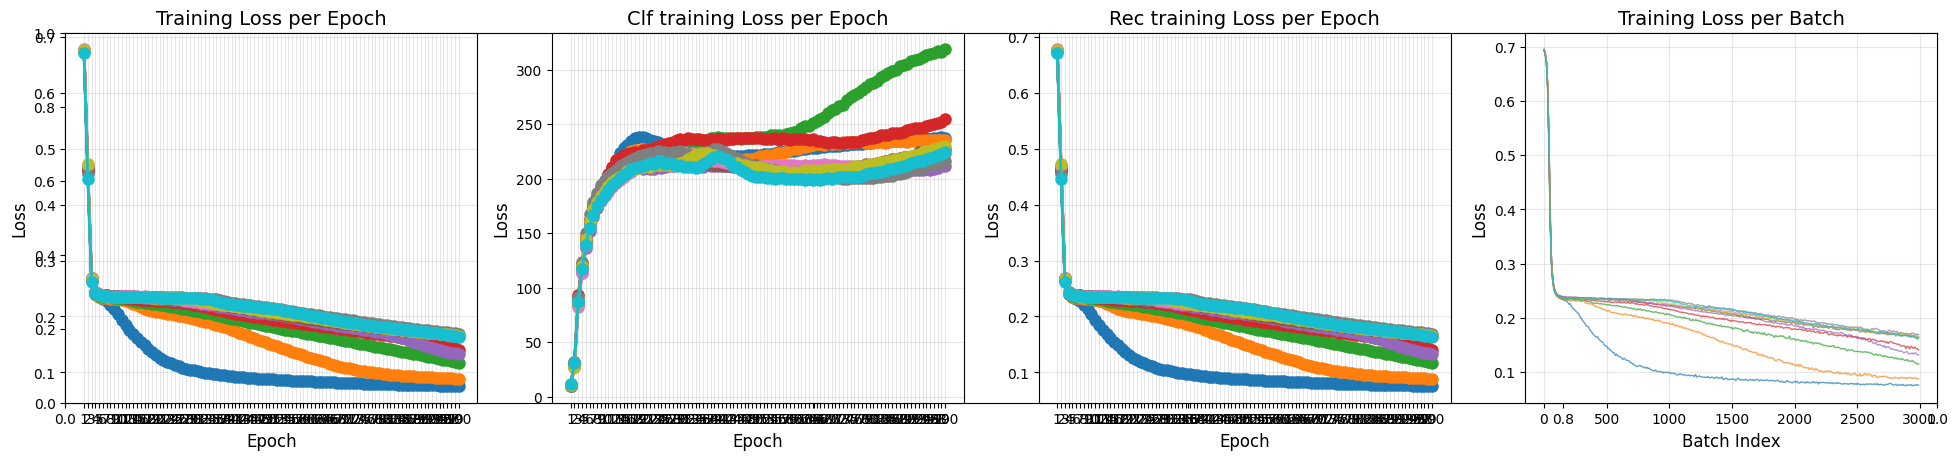

In [ ]:

import matplotlib.pyplot as plt
import torch
fig, ax = plt.subplots(figsize=(20, 5))
for max_offset in max_move_l:
    model_path = f"{save_dir}/model_max_offset_{max_offset}.pt"
    checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)
    epoch_losses = checkpoint.get("epoch_losses", None)
    batch_losses = checkpoint.get("batch_losses", None)
    epoch_losses_clf = checkpoint.get("epoch_losses_clf", None)
    epoch_losses_rec = checkpoint.get("epoch_losses_rec", None)
    if epoch_losses is not None and batch_losses is not None:
        plot_training_loss(epoch_losses, batch_losses, fig=fig, label=f"max_offset={max_offset}", epoch_losses_clf=epoch_losses_clf, epoch_losses_rec=epoch_losses_rec)

# ax.set_title("Training Loss for Each max_offset")
# ax.legend()
plt.show()

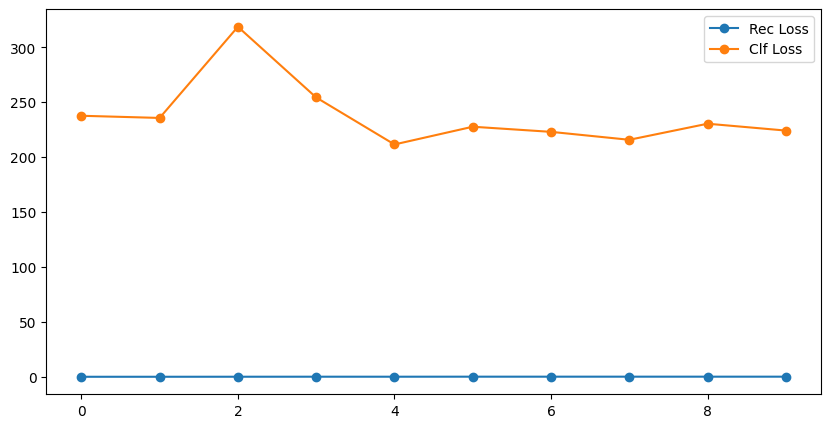

In [ ]:

import matplotlib.pyplot as plt
import torch
fig, ax = plt.subplots(figsize=(10, 5))
rec_losses = []
clf_losses = []
for max_offset in max_move_l:
    model_path = f"{save_dir}/model_max_offset_{max_offset}.pt"
    checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)
    epoch_losses = checkpoint.get("epoch_losses", None)
    batch_losses = checkpoint.get("batch_losses", None)
    epoch_losses_clf = checkpoint.get("epoch_losses_clf", None)
    epoch_losses_rec = checkpoint.get("epoch_losses_rec", None)
    rec_losses.append(epoch_losses_rec[-1])
    clf_losses.append(epoch_losses_clf[-1])
plt.plot(max_move_l, rec_losses, marker='o', label='Rec Loss')
plt.plot(max_move_l, clf_losses, marker='o', label='Clf Loss')
plt.legend()
plt.show()

In [ ]:
# ----------------------------
# 6. PCA visualization of latent space
# ----------------------------
def plot_latent_pca_order(model, test_loader, device='cuda', plot_label=None, layer='encoder'):
    """Plot 2D PCA of latent representations colored by target digit"""
    from sklearn.decomposition import PCA
    import numpy as np
    
    model.eval()
    latent_vectors = []
    target_digits = []
    
    with torch.no_grad():
        for x, offset, target, label, target_digit in test_loader:
            x, offset, label, target_digit = x.to(device), offset.to(device), label.to(device), target_digit.to(device)
            
            # Get latent representation (output of fc2 layer)
            # Forward pass through the new model architecture to get latent representation
            z = model.get_latent(x, offset, layer=layer)

            # Store latent vectors and corresponding target digits
            latent_vectors.append(z.cpu().numpy())
            target_digits.extend(target_digit.tolist())
    
    # Concatenate all latent vectors
    latent_vectors = np.concatenate(latent_vectors, axis=0)
    target_digits = np.array(target_digits)
    
    # Apply PCA to reduce to 2D
    pca = PCA()
    latent_pca = pca.fit_transform(latent_vectors)
    
    # Print explained variance
    print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")

    # Compute and plot R^2 of regression between first n PCs and target digits for n=1 up to latent dimension
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import r2_score

    latent_dim = latent_vectors.shape[1]
    r2_scores = []

    # For each n from 1 to latent_dim, fit regression and compute R^2
    for n in range(1, 11):
        pcs = latent_pca[:, :n]
        reg = LinearRegression()
        reg.fit(pcs, target_digits)
        preds = reg.predict(pcs)
        r2 = r2_score(target_digits, preds)
        r2_scores.append(r2)

    
    def circular_r2(points, labels, n_labels=10):
        # Center data
        points = points - points.mean(axis=0)
        
        # Map labels to angles
        angles = 2 * np.pi * (labels - 1) / n_labels
        
        # Ideal points on unit circle
        ideal = np.stack([np.cos(angles), np.sin(angles)], axis=1)
        
        # Scale ideal points to best fit actual points (linear least-squares)
        A = np.linalg.lstsq(ideal, points, rcond=None)[0]
        fitted = ideal @ A
        
        # Compute R²-like score
        ss_res = np.sum((points - fitted)**2)
        ss_tot = np.sum((points - points.mean(axis=0))**2)
        r2_circ = 1 - ss_res / ss_tot
        return r2_circ

    r2_scores_circle = circular_r2(latent_pca[:,:2], target_digits)

    # plt.figure(figsize=(7, 4))
    plt.plot(range(1, 11), r2_scores, marker='o', label=plot_label)
    plt.xlabel('Number of Principal Components used')
    plt.ylabel('$R^2$ (regression on target digit)')
    plt.title('$R^2$ of regression: target digit vs. first $n$ PCs')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.show()

    NC1 = calc_NC1(latent_vectors, target_digits)
    
    return latent_pca, target_digits, pca, r2_scores, r2_scores_circle, NC1

In [ ]:
def create_test_loader_for_viz(max_offset=3, batch_size=128, max_offset_sample=None):
    """Create a test data loader for visualization purposes"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda t: t.view(-1))  # flatten
    ])
    mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
    
    test_ds = DigitOffsetDataset(mnist_test, max_offset=max_offset, max_offset_sample=max_offset_sample)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    return test_loader

Explained variance: PC1=0.263, PC2=0.218
Explained variance: PC1=0.344, PC2=0.158
Explained variance: PC1=0.492, PC2=0.134
Explained variance: PC1=0.567, PC2=0.170
Explained variance: PC1=0.620, PC2=0.153
Explained variance: PC1=0.657, PC2=0.160
Explained variance: PC1=0.659, PC2=0.153
Explained variance: PC1=0.677, PC2=0.142
Explained variance: PC1=0.697, PC2=0.137
Explained variance: PC1=0.663, PC2=0.157


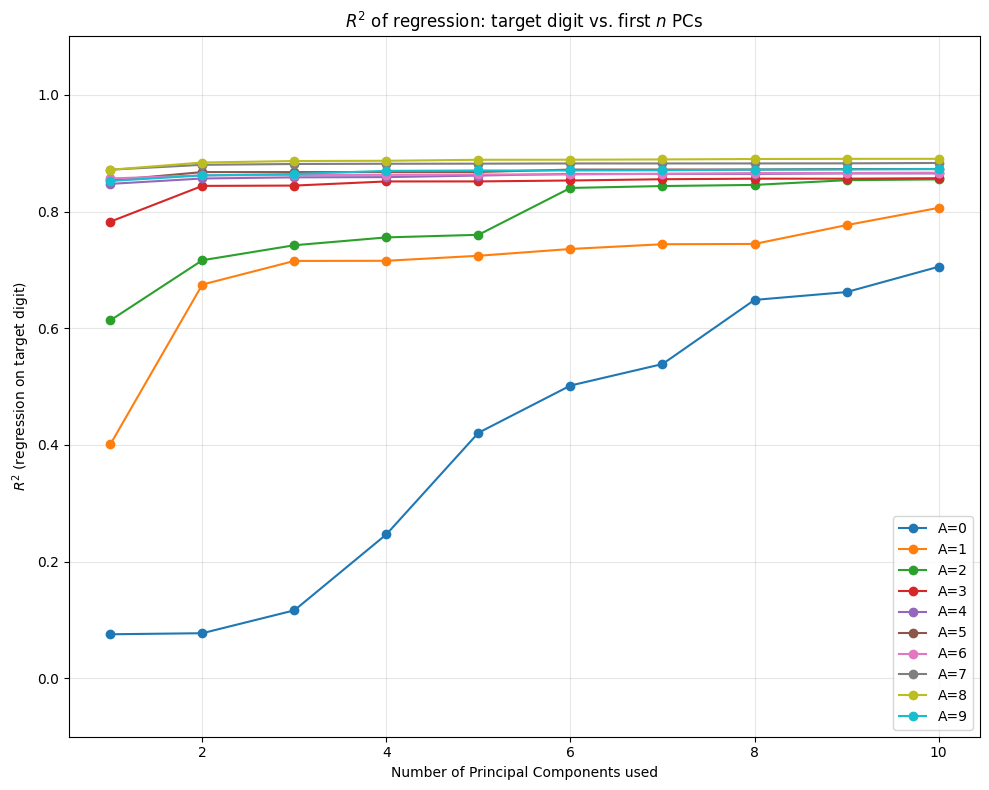

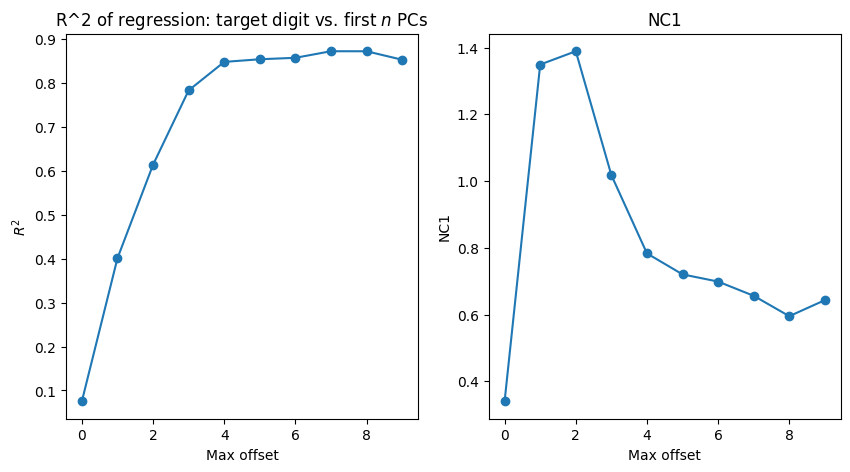

In [ ]:
r2_scores_l = []
NC1_l = []
fig = plt.figure(figsize=(10, 8))
for max_offset in max_move_l:
    model_path = f"{save_dir}/model_max_offset_{max_offset}.pt"
    checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)
    model = DigitTranslator(offset_dim=2*max_offset+1, n_layers_encoder=n_layers, n_layers_decoder=n_layers).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    # Create test loader for visualization
    test_loader_viz = create_test_loader_for_viz(max_offset=max_offset, batch_size=128)

    # Plot PCA of latent space
    latent_2d, target_digits, pca, r2_scores, r2_scores_circle, NC1 = plot_latent_pca_order(model, test_loader_viz, device=device, plot_label=f"A={max_offset}", layer='encoder')
    r2_scores_l.append(r2_scores)
    NC1_l.append(NC1)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(max_move_l,[r2_scores[0] for r2_scores in r2_scores_l], marker='o')
axs[1].plot(max_move_l,NC1_l, marker='o')
axs[0].set_title('R^2 of regression: target digit vs. first $n$ PCs')
axs[1].set_title('NC1')
axs[0].set_xlabel('Max offset')
axs[1].set_xlabel('Max offset')
axs[0].set_ylabel('$R^2$')
axs[1].set_ylabel('NC1')
plt.show()

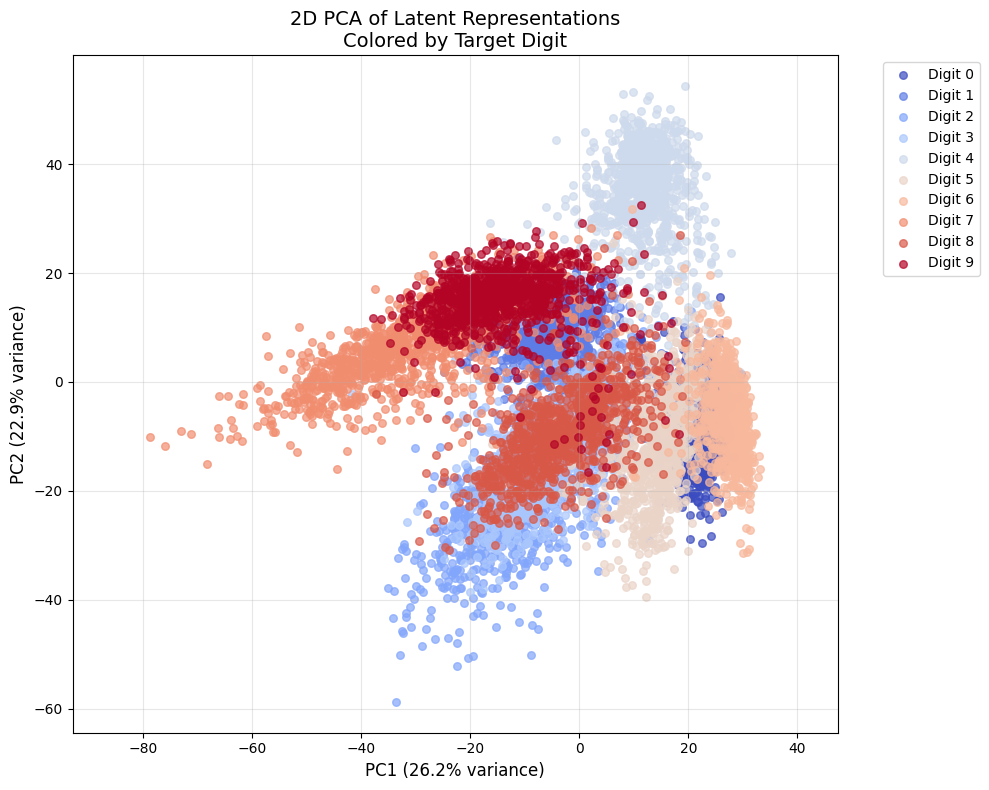

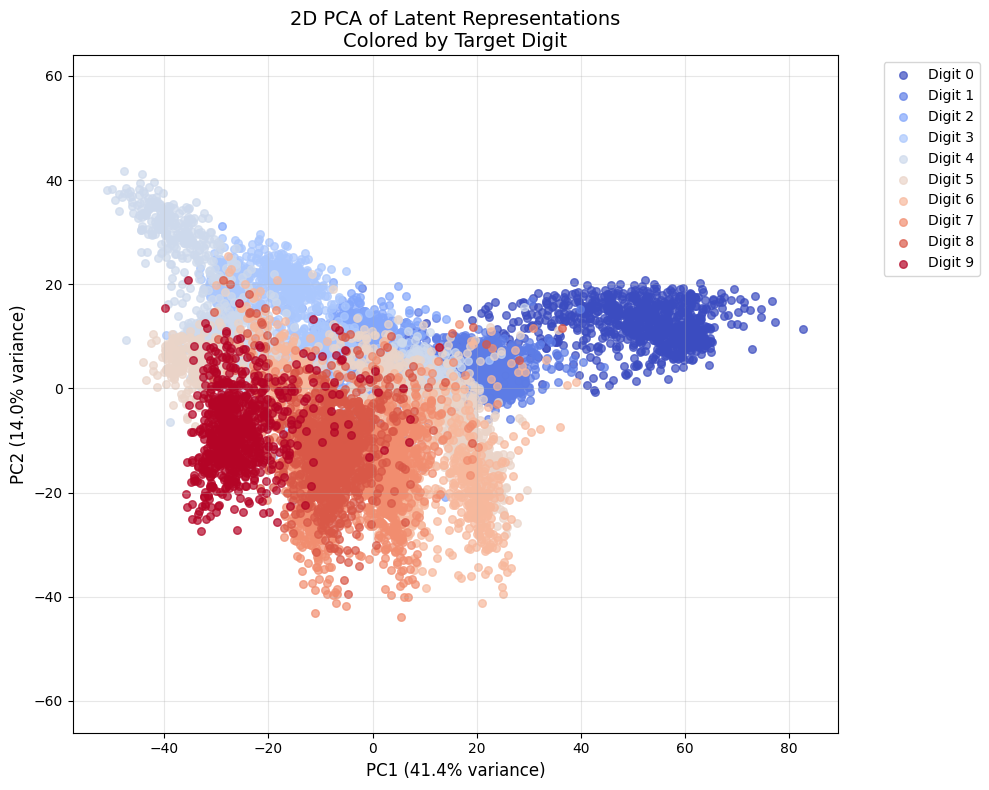

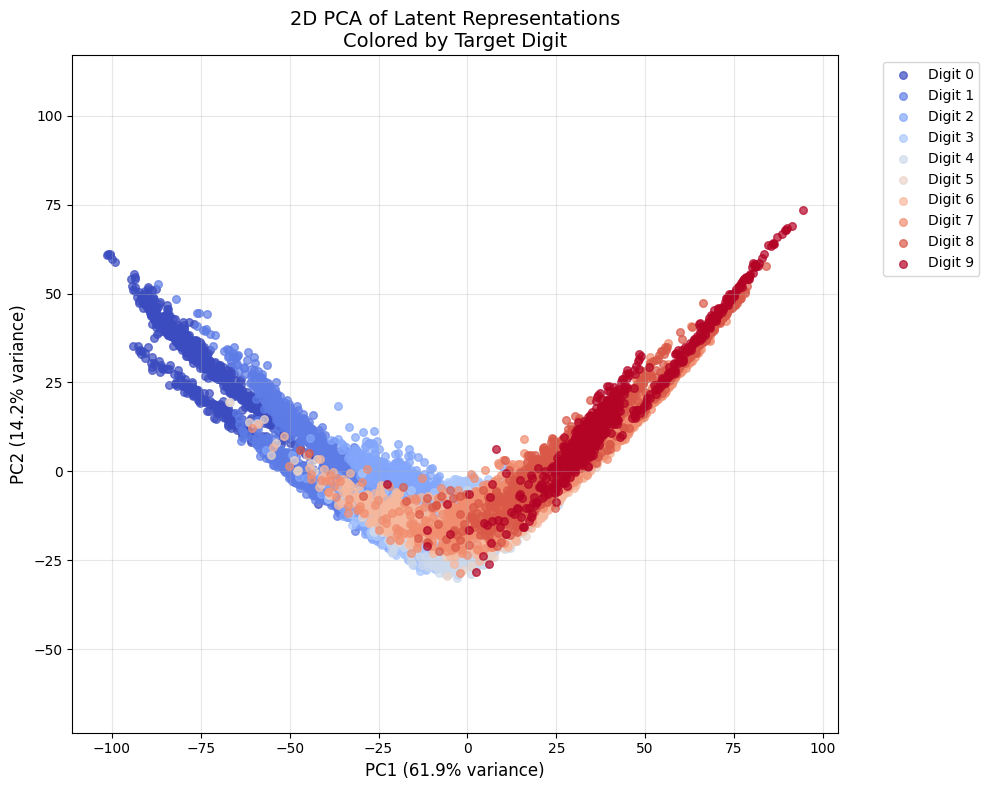

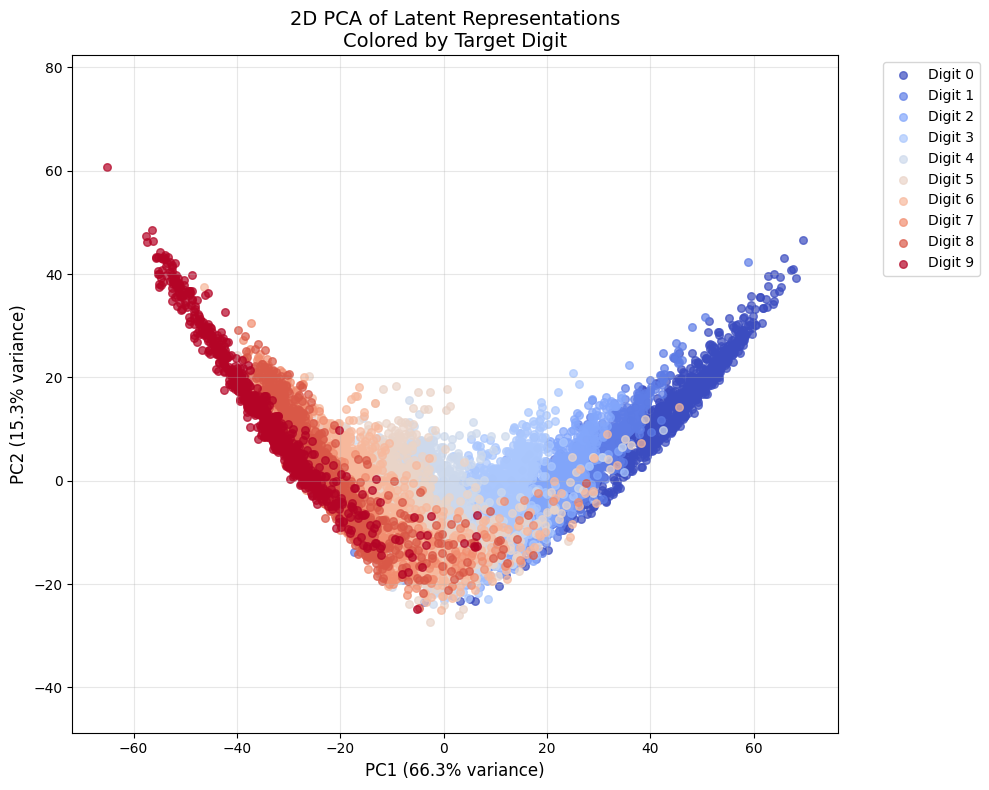

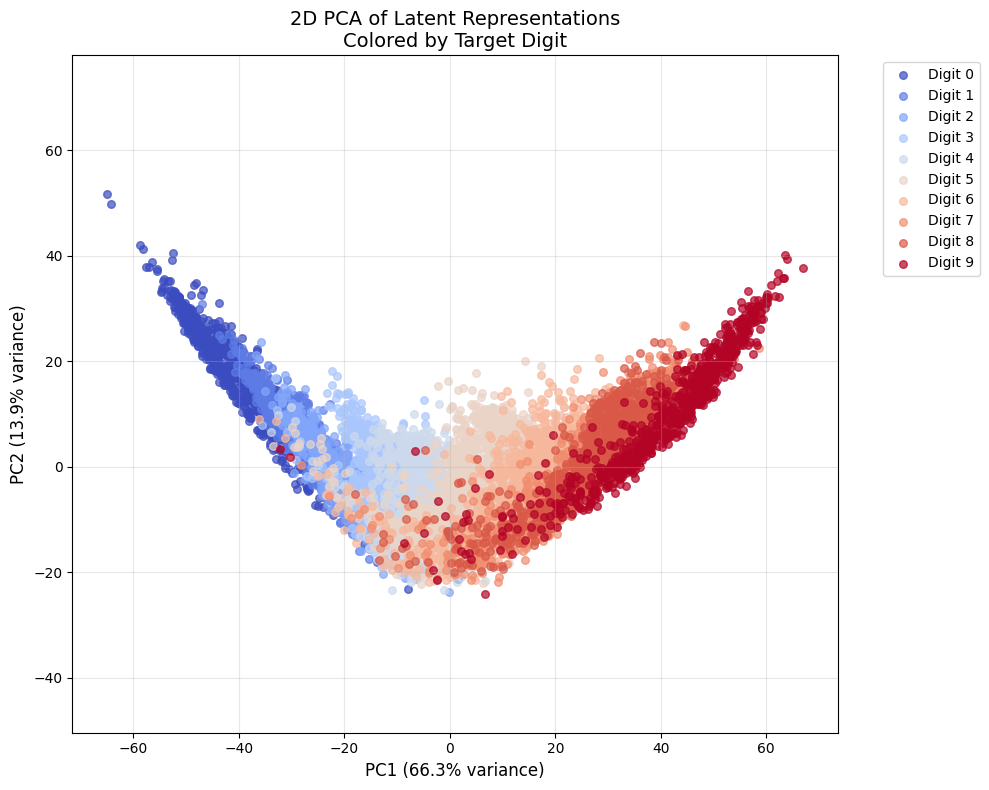

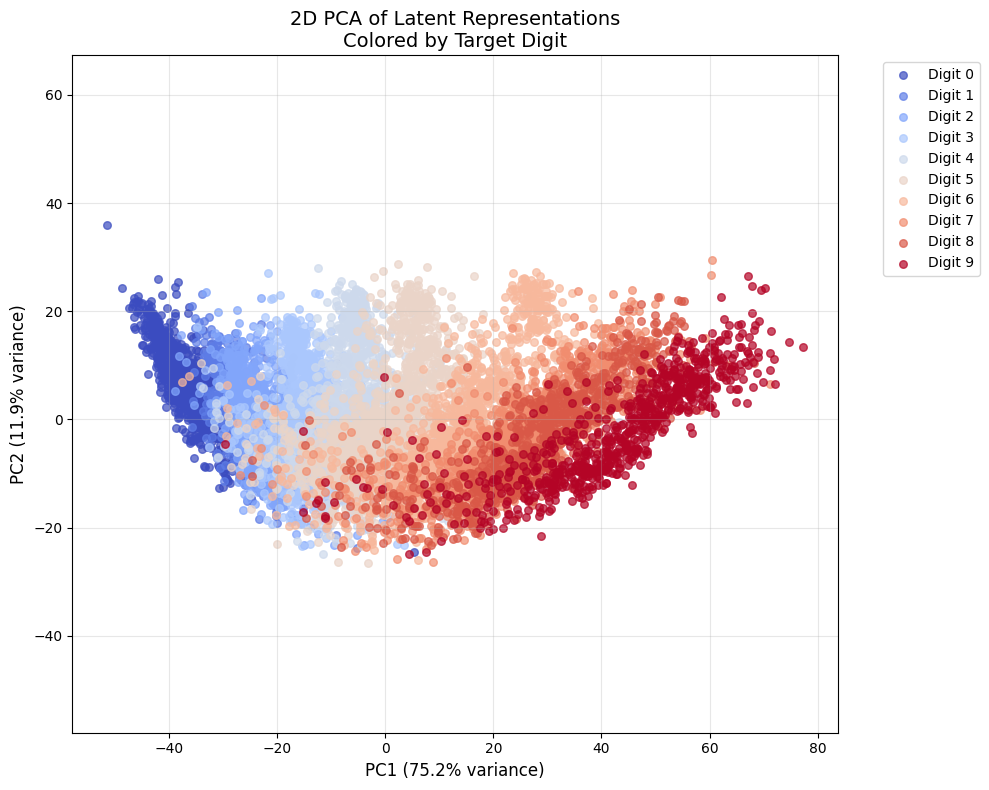

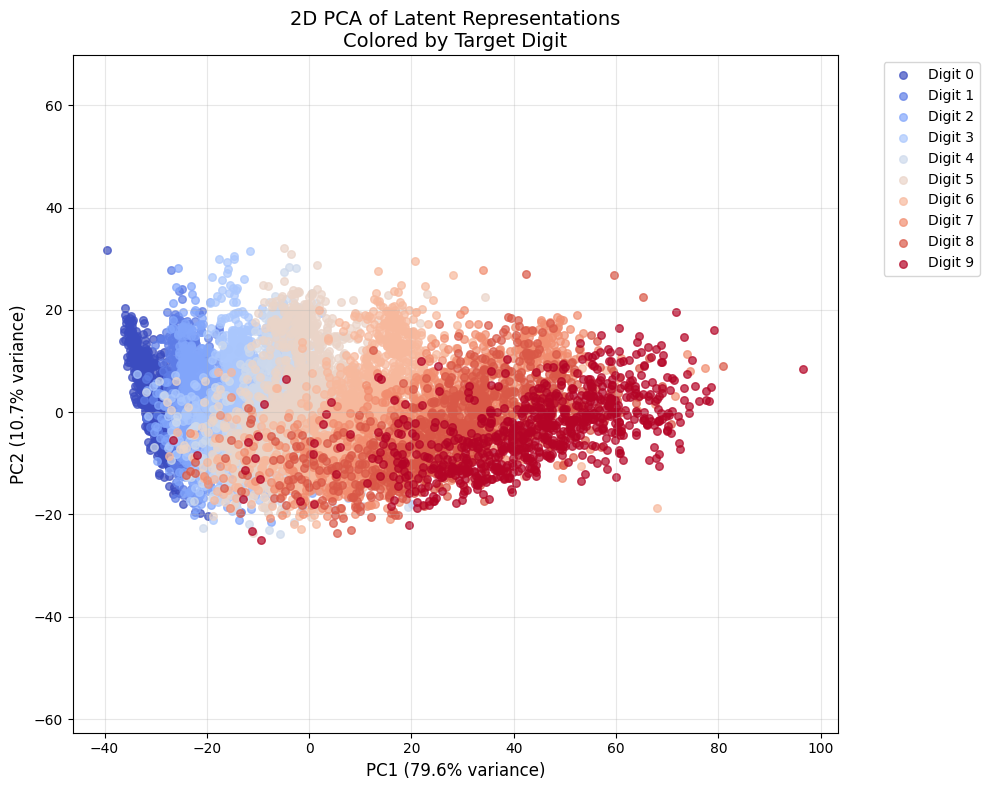

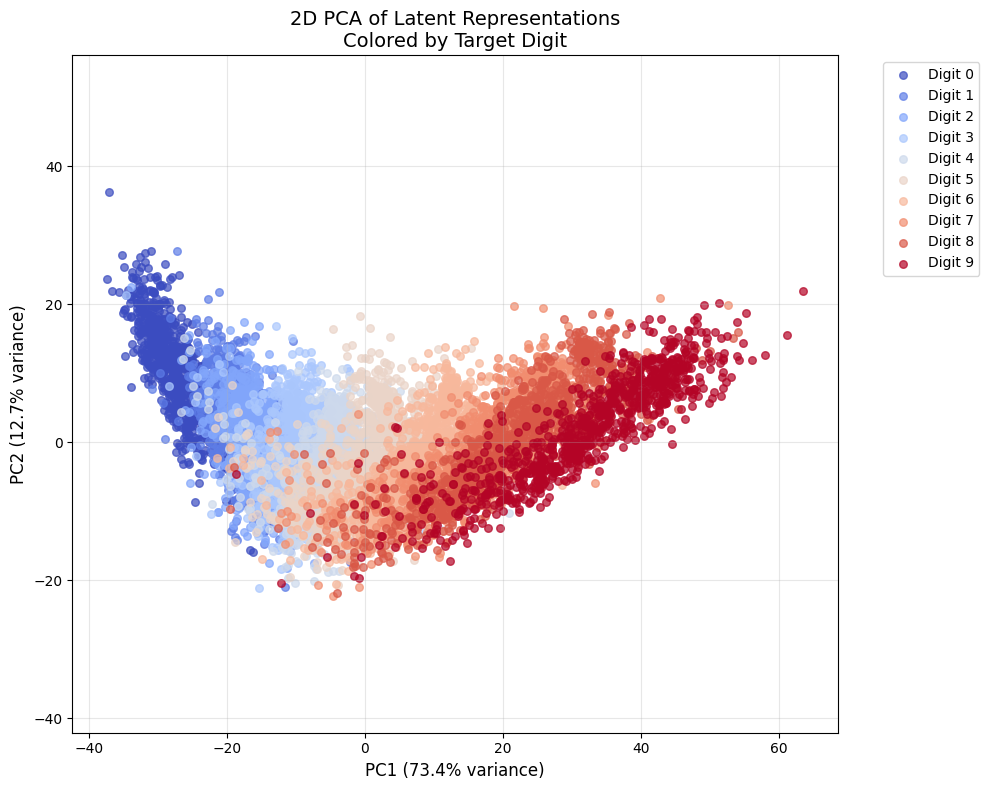

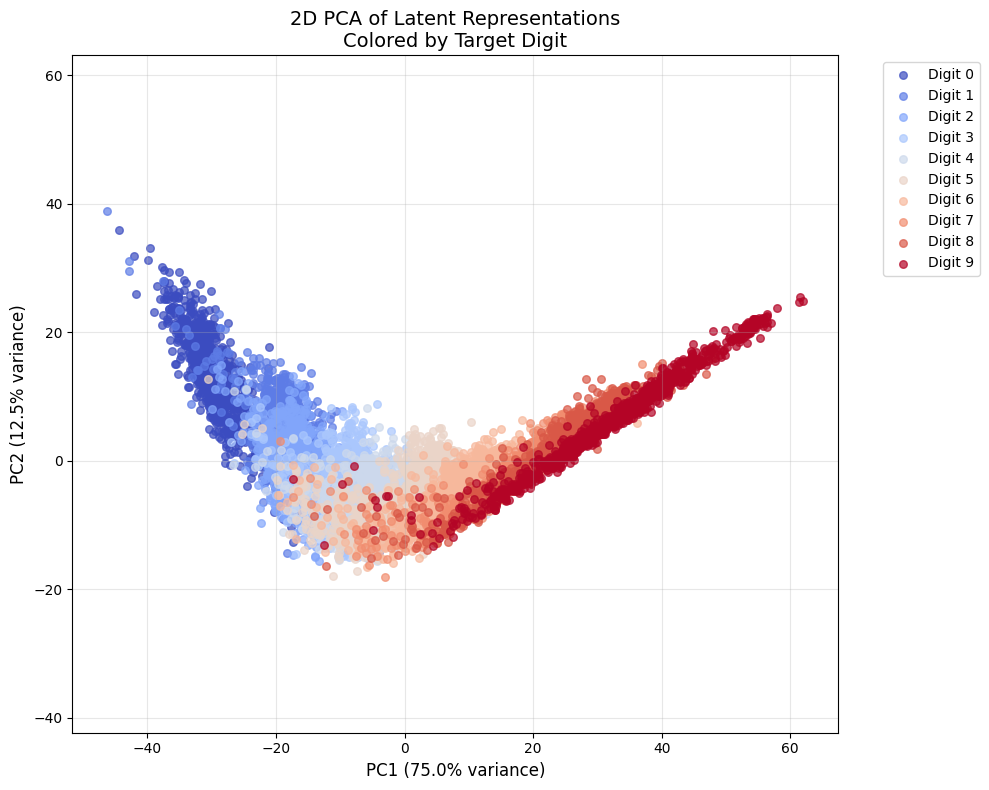

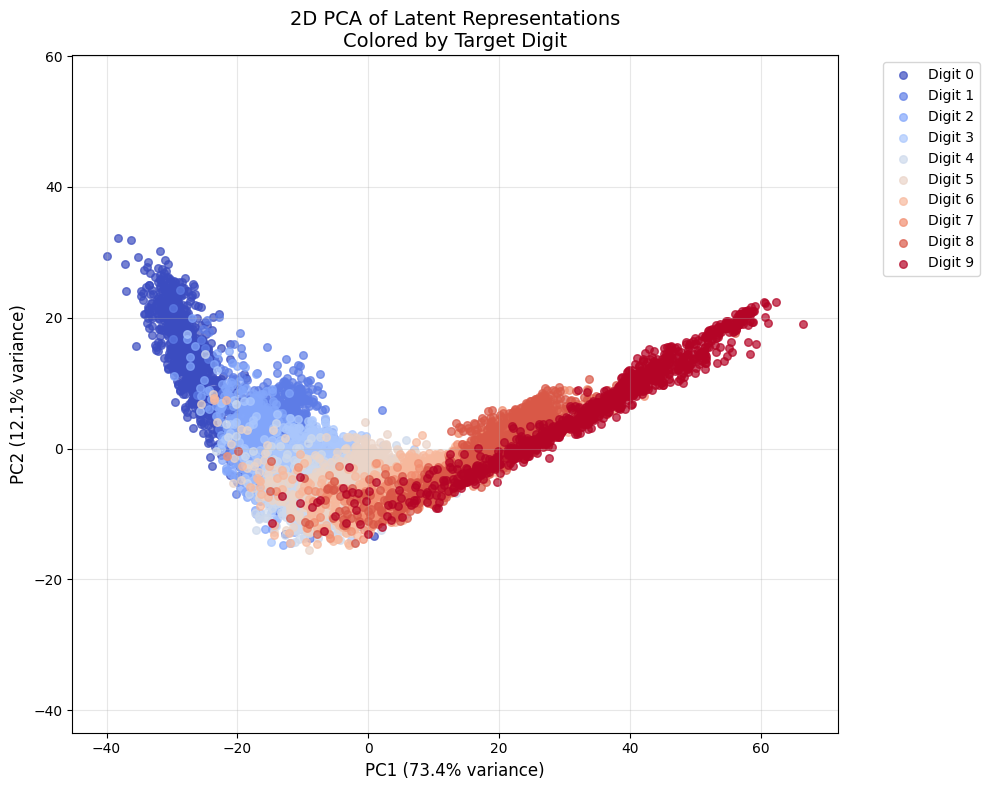


Epoch 90, Loss: 0.1498, Elapsed Time: 23.71 minutes, Estimated Remaining Time: 2.63 minutes
Epoch 91, Loss: 0.1477, Elapsed Time: 23.97 minutes, Estimated Remaining Time: 2.37 minutes
Epoch 92, Loss: 0.1454, Elapsed Time: 24.23 minutes, Estimated Remaining Time: 2.11 minutes
Epoch 93, Loss: 0.1437, Elapsed Time: 24.49 minutes, Estimated Remaining Time: 1.84 minutes
Epoch 94, Loss: 0.1416, Elapsed Time: 24.75 minutes, Estimated Remaining Time: 1.58 minutes
Epoch 95, Loss: 0.1400, Elapsed Time: 25.02 minutes, Estimated Remaining Time: 1.32 minutes
Epoch 96, Loss: 0.1383, Elapsed Time: 25.28 minutes, Estimated Remaining Time: 1.05 minutes
Epoch 97, Loss: 0.1368, Elapsed Time: 25.54 minutes, Estimated Remaining Time: 0.79 minutes
Epoch 98, Loss: 0.1349, Elapsed Time: 25.80 minutes, Estimated Remaining Time: 0.53 minutes
Epoch 99, Loss: 0.1337, Elapsed Time: 26.06 minutes, Estimated Remaining Time: 0.26 minutes
Epoch 100, Loss: 0.1325, Elapsed Time: 26.32 minutes, Estimated Remaining Time:

In [ ]:
def plot_latent_pca(model, test_loader, device='cuda', plot_label=None):
    """Plot 2D PCA of latent representations colored by target digit"""
    from sklearn.decomposition import PCA
    import numpy as np
    
    model.eval()
    latent_vectors = []
    target_digits = []
    
    with torch.no_grad():
        for x, offset, target, label, target_digit in test_loader:
            x, offset, label, target_digit = x.to(device), offset.to(device), label.to(device), target_digit.to(device)
            
            # Get latent representation (output of fc2 layer)
            # Forward pass through the new model architecture to get latent representation
            z = model.get_latent(x, offset, layer='decoder')

            # Store latent vectors and corresponding target digits
            latent_vectors.append(z.cpu().numpy())
            target_digits.extend(target_digit.tolist())
    
    # Concatenate all latent vectors
    latent_vectors = np.concatenate(latent_vectors, axis=0)
    target_digits = np.array(target_digits)
    
    # Apply PCA to reduce to 2D
    pca = PCA()
    latent_pca = pca.fit_transform(latent_vectors)
    
    # Create the plot
    plt.figure(figsize=(10, 8))
    
    # Plot each digit with different colors
    colors = plt.cm.coolwarm(np.linspace(0, 1, 10))
    for digit in range(10):
        mask = target_digits == digit
        plt.scatter(latent_pca[mask, 0], latent_pca[mask, 1], 
                   c=[colors[digit]], label=f'Digit {digit}', 
                   alpha=0.7, s=30,)
    
    plt.title('2D PCA of Latent Representations\nColored by Target Digit', fontsize=14)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    plt.axis('equal')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

for max_offset in max_move_l:
    model_path = f"{save_dir}/model_max_offset_{max_offset}.pt"
    checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)
    model = DigitTranslator(offset_dim=2*max_offset+1, n_layers_encoder=n_layers, n_layers_decoder=n_layers).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    # Create test loader for visualization
    test_loader_viz = create_test_loader_for_viz(max_offset=max_offset, batch_size=128)

    # Plot PCA of latent space
    plot_latent_pca(model, test_loader_viz, device=device, plot_label=f"A={max_offset}")